In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Yuvaraj singh\Downloads\ecommerce_sales.csv.zip")

#  DATA CLEANING

In [3]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [4]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [5]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [6]:
# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# EXPLORATORY DATA ANALYSIS

In [7]:
print("\nBasic Statistics:\n", df.describe())


Basic Statistics:
             Row ID                     Order Date         Sales     Quantity  \
count  9994.000000                           9994   9994.000000  9994.000000   
mean   4997.500000  2016-04-30 00:07:12.259355648    229.858001     3.789574   
min       1.000000            2014-01-03 00:00:00      0.444000     1.000000   
25%    2499.250000            2015-05-23 00:00:00     17.280000     2.000000   
50%    4997.500000            2016-06-26 00:00:00     54.490000     3.000000   
75%    7495.750000            2017-05-14 00:00:00    209.940000     5.000000   
max    9994.000000            2017-12-30 00:00:00  22638.480000    14.000000   
std    2885.163629                            NaN    623.245101     2.225110   

          Discount       Profit         Year        Month  
count  9994.000000  9994.000000  9994.000000  9994.000000  
mean      0.156203    28.656896  2015.722233     7.809686  
min       0.000000 -6599.978000  2014.000000     1.000000  
25%       0.000000 

In [8]:
# Total Sales
total_sales = df['Sales'].sum()
print("\nTotal Sales:", total_sales)


Total Sales: 2297200.8603000003


In [9]:
# Total Profit
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [10]:
# Top 5 Products by Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Products:\n", top_products)


Top 5 Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64


# DATA VISUALIZATION

In [11]:
sns.set_style("whitegrid")

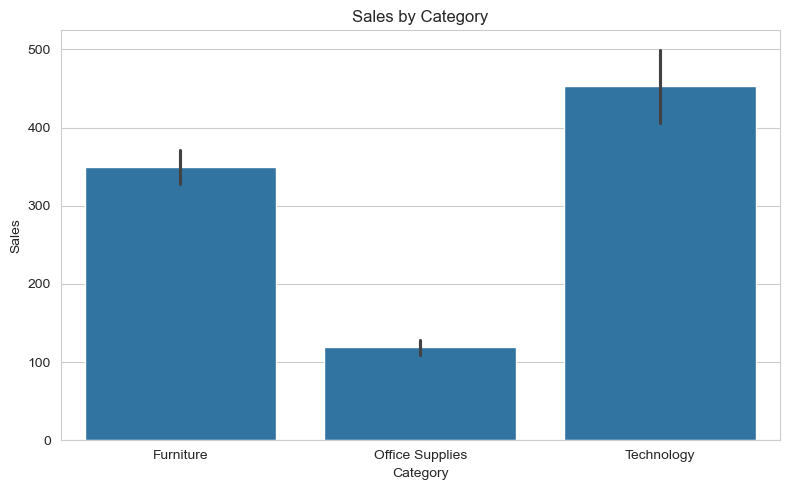

In [20]:
# 1. Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

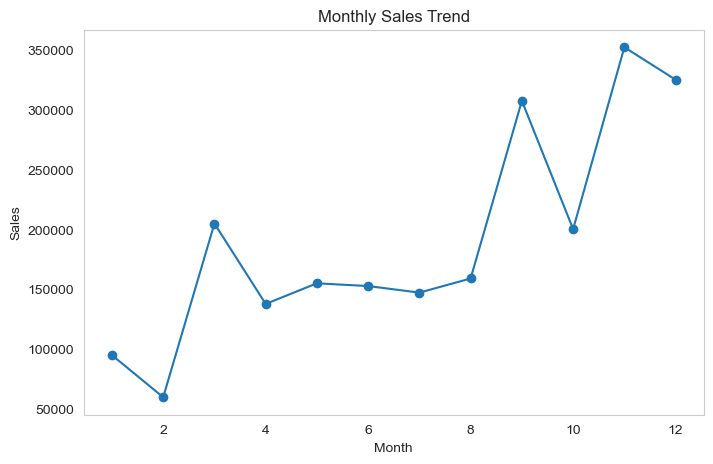

In [13]:
# 2. Monthly Sales Trend
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

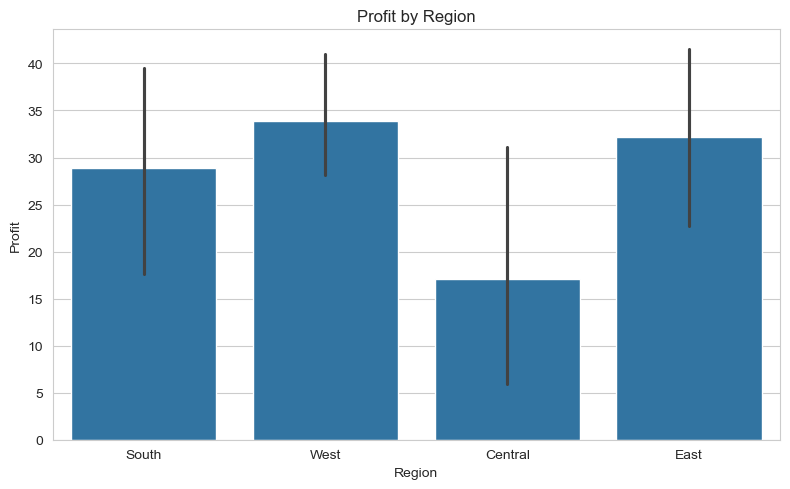

In [21]:
# 3. Profit by Region
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

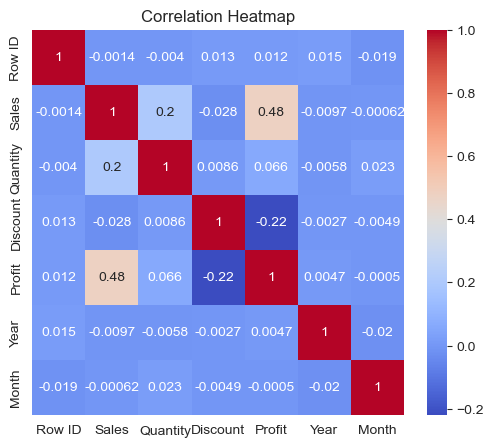

In [15]:
# 4. Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
print("\nAnalysis Completed Successfully!")


Analysis Completed Successfully!
